# LEVEL-2

### TASK 1: Restaurant Ratings

Distribution of Aggregate Ratings:
Rating Range
0-1    2148
1-2      10
2-3    1891
3-4    4388
4-5    1114
Name: count, dtype: int64

Most common rating range: 3-4 (4388 restaurants)

Average number of votes received by restaurants: 156.91


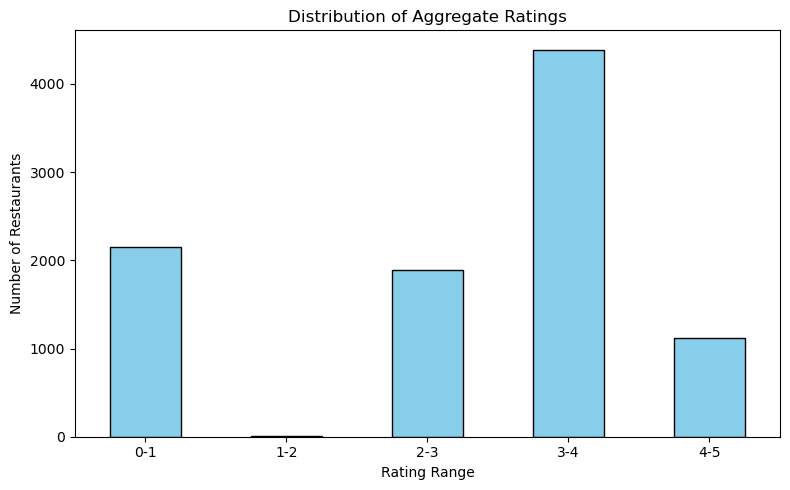


Chart saved as: level2_task1_rating_distribution.png


In [1]:
"""
Cognifyz Technologies - Data Analysis Internship
LEVEL 2 - TASK 1: Restaurant Ratings
"""

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Dataset.csv')

# ------------------------------------------------------------
# 1. Analyze the distribution of aggregate ratings
# ------------------------------------------------------------
rating_bins = [0, 1, 2, 3, 4, 5]
rating_labels = ['0-1', '1-2', '2-3', '3-4', '4-5']

df['Rating Range'] = pd.cut(
    df['Aggregate rating'],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True
)

rating_dist = df['Rating Range'].value_counts().sort_index()

print("Distribution of Aggregate Ratings:")
print(rating_dist)

# Most common rating range
most_common_range = rating_dist.idxmax()
print(f"\nMost common rating range: {most_common_range} "
      f"({rating_dist.max()} restaurants)")

# ------------------------------------------------------------
# 2. Calculate the average number of votes
# ------------------------------------------------------------
avg_votes = df['Votes'].mean()
print(f"\nAverage number of votes received by restaurants: {avg_votes:.2f}")

# ------------------------------------------------------------
# 3. Visualize the rating distribution
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
rating_dist.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Rating Range')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('level2_task1_rating_distribution.png', dpi=150)
plt.show()

print("\nChart saved as: level2_task1_rating_distribution.png")

### TASK 2: Cuisine Combination

In [2]:
"""
LEVEL 2 - TASK 2: Cuisine Combination
"""

import pandas as pd

# Load dataset
df = pd.read_csv('Dataset.csv')
df['Cuisines'] = df['Cuisines'].fillna('')

# ------------------------------------------------------------
# 1. Identify the most common combinations of cuisines
# ------------------------------------------------------------
combo_counts = df['Cuisines'].value_counts().head(10)

print("Top 10 most common cuisine combinations:")
print(combo_counts)

# ------------------------------------------------------------
# 2. Determine if certain cuisine combinations tend to have
#    higher ratings
# ------------------------------------------------------------
# Only consider combinations with a reasonable sample size
# (avoids one-off combos with a single 5.0 rating skewing results)
combo_ratings = df.groupby('Cuisines')['Aggregate rating'].agg(['mean', 'count'])
combo_ratings = combo_ratings[combo_ratings['count'] >= 10].sort_values('mean', ascending=False)

print("\nTop 10 cuisine combinations (min. 10 restaurants) by average rating:")
print(combo_ratings.head(10))

print("\nBottom 10 cuisine combinations (min. 10 restaurants) by average rating:")
print(combo_ratings.tail(10))

Top 10 most common cuisine combinations:
Cuisines
North Indian                      936
North Indian, Chinese             511
Fast Food                         354
Chinese                           354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

Top 10 cuisine combinations (min. 10 restaurants) by average rating:
                                mean  count
Cuisines                                   
Modern Indian               4.345455     11
Indian                      4.250000     18
Seafood                     4.114286     14
Thai                        4.100000     16
Cafe, Continental, Italian  4.080000     10
American, Burger            4.076923     13
Japanese, Sushi             4.044444     18
Pizza, Italian              3.668421     19
American                    3.6677

###  TASK 3: Geographic Analysis

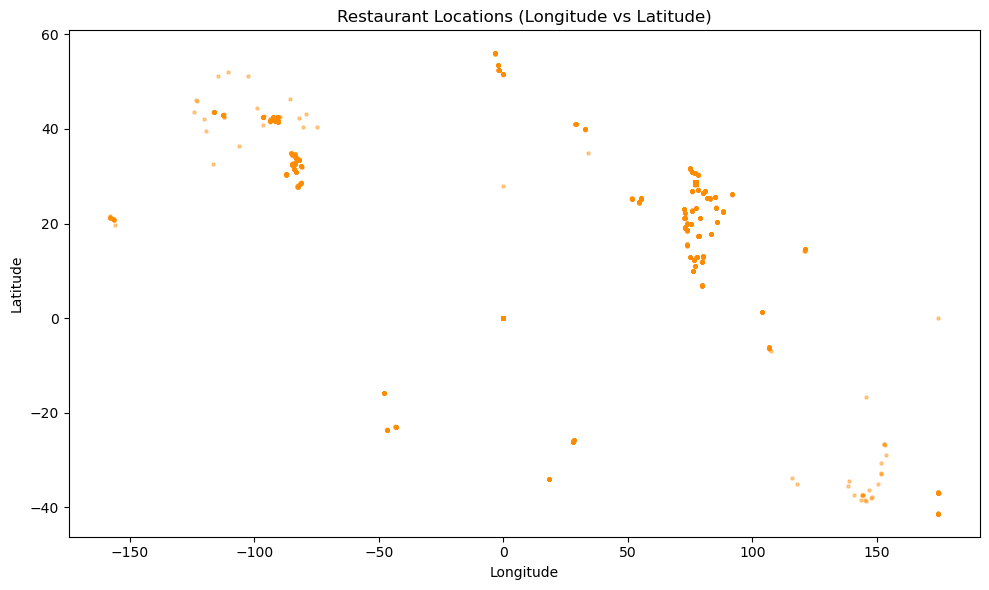

Chart saved as: level2_task3_geographic_scatter.png

Top 10 cities by restaurant count (clustering hotspots):
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


In [3]:
"""
LEVEL 2 - TASK 3: Geographic Analysis
"""

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Dataset.csv')

# ------------------------------------------------------------
# 1. Plot the locations of restaurants using longitude/latitude
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(df['Longitude'], df['Latitude'], s=5, alpha=0.4, c='darkorange')
plt.title('Restaurant Locations (Longitude vs Latitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('level2_task3_geographic_scatter.png', dpi=150)
plt.show()

print("Chart saved as: level2_task3_geographic_scatter.png")

# ------------------------------------------------------------
# 2. Identify patterns or clusters of restaurants in specific areas
# ------------------------------------------------------------
city_counts = df['City'].value_counts().head(10)
print("\nTop 10 cities by restaurant count (clustering hotspots):")
print(city_counts)

# Optional: zoomed-in view of the densest cluster (helps confirm
# that most points sit in a tight geographic band, e.g. NCR region)
top_city = city_counts.idxmax()
top_city_df = df

### TASK 4: Restaurant Chains

In [4]:
"""
LEVEL 2 - TASK 4: Restaurant Chains
"""

import pandas as pd

# Load dataset
df = pd.read_csv('Dataset.csv')

# ------------------------------------------------------------
# 1. Identify if there are any restaurant chains present
# ------------------------------------------------------------
# A "chain" = same restaurant name appearing more than once (multiple outlets)
name_counts = df['Restaurant Name'].value_counts()
chains = name_counts[name_counts > 1]

print(f"Number of restaurant names appearing more than once (chains): {len(chains)}")
print("\nTop 10 restaurant chains by outlet count:")
print(chains.head(10))

# ------------------------------------------------------------
# 2. Analyze the ratings and popularity of different chains
# ------------------------------------------------------------
chain_stats = df[df['Restaurant Name'].isin(chains.index)].groupby('Restaurant Name').agg(
    Outlets=('Restaurant Name', 'count'),
    Avg_Rating=('Aggregate rating', 'mean'),
    Total_Votes=('Votes', 'sum')
).sort_values('Outlets', ascending=False)

print("\nTop 10 chains by outlet count - avg rating & total votes:")
print(chain_stats.head(10))

print("\nTop 10 chains by average rating (min. 5 outlets):")
print(chain_stats[chain_stats['Outlets'] >= 5].sort_values('Avg_Rating', ascending=False).head(10))

print("\nTop 10 chains by popularity (total votes):")
print(chain_stats.sort_values('Total_Votes', ascending=False).head(10))

Number of restaurant names appearing more than once (chains): 734

Top 10 restaurant chains by outlet count:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

Top 10 chains by outlet count - avg rating & total votes:
                  Outlets  Avg_Rating  Total_Votes
Restaurant Name                                   
Cafe Coffee Day        83    2.419277         2428
Domino's Pizza         79    2.740506         6643
Subway                 63    2.907937         6124
Green Chick Chop       51    2.672549          964
McDonald's             48    3.339583         5291
Keventers              34    2.870588         1263
Pizza Hut              30    3.320000         4961
Giani                  29    2.689655          854
Baskin Robbins         28    1.860714          428